In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math

sns.set(style="whitegrid")


In [3]:
# ==== BASE PATH ====
base_path = r"D:\004. HK2 Năm 3\01. DS108\OpenSetDGA-Detection\dataset_out\run_20260222_193219"

# ==== PATHS ====
train_path = base_path + r"\known\train.csv"
val_path = base_path + r"\known\val.csv"
test_known_path = base_path + r"\known\test_known.csv"
unknown_family_path = base_path + r"\unknown_family\test_unknown_family.csv"
unknown_ood_path = base_path + r"\unknown_ood\test_unknown_ood.csv"

# ==== LOAD DATA ====
df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)
df_test_known = pd.read_csv(test_known_path)
df_unknown_family = pd.read_csv(unknown_family_path)
df_unknown_ood = pd.read_csv(unknown_ood_path)

print("Loaded successfully!")


Loaded successfully!


## Thống kê cơ bản

In [4]:
print("Dataset sizes:")
print(f"Train: {df_train.shape}")
print(f"Test Known (ID): {df_test_known.shape}")
print(f"Unknown Family: {df_unknown_family.shape}")
print(f"Unknown OOD: {df_unknown_ood.shape}")


Dataset sizes:
Train: (320000, 7)
Test Known (ID): (40000, 7)
Unknown Family: (50000, 7)
Unknown OOD: (100000, 7)


In [ ]:
# Kiểm tra phân bố label trong train
print("\nTrain label distribution:")
print(df_train["label"].value_counts())

print("\nTrain family distribution (top 10):")
print(df_train["family"].value_counts().head(10))



Train label distribution:
label
dga       160083
benign    159917
Name: count, dtype: int64

Train family distribution (top 10):
family
benign      159917
nymaim        9225
simda         9211
ramdo         9194
pykspa        9191
rovnix        9190
suppobox      9181
dircrypt      9173
matsnu        9171
padcrypt      9169
Name: count, dtype: int64


In [7]:
#Check missing value
print("\nMissing values check:")
print(df_train.isnull().sum())



Missing values check:
domain         0
family         0
source         0
label          0
split          0
class_label    0
split_hint     0
dtype: int64


In [ ]:
# Kiểm tra Unknown Family có overlap với Train không
train_families = set(df_train["family"].unique())
unknown_families = set(df_unknown_family["family"].unique())

print("Overlap families:", train_families.intersection(unknown_families))


Overlap families: set()


In [9]:
# Kiểm tra Unknown OOD có label gì
print(df_unknown_ood["label"].value_counts())
print(df_unknown_ood["source"].value_counts().head(10))


label
ood    100000
Name: count, dtype: int64
source
phishing.army:phishing_army_blocklist.txt          40000
raw.githubusercontent.com:hagezi/dns-blocklists    36382
tranco_tail                                        18891
raw.githubusercontent.com:stamparm/blackbook        3618
crtsh                                                412
360netlab                                            324
urlhaus.abuse.ch:text_online                         322
openphish.com:feed.txt                                51
Name: count, dtype: int64


In [10]:
# Kiểm tra domain trùng giữa các tập
train_domains = set(df_train["domain"])
test_domains = set(df_test_known["domain"])
unknown_domains = set(df_unknown_family["domain"])

print("Train & Test overlap:", len(train_domains.intersection(test_domains)))
print("Train & Unknown overlap:", len(train_domains.intersection(unknown_domains)))


Train & Test overlap: 0
Train & Unknown overlap: 0


In [11]:
# Kiểm tra phân phối length giữa các tập
df_train["length"] = df_train["domain"].apply(len)
df_unknown_ood["length"] = df_unknown_ood["domain"].apply(len)

print(df_train["length"].describe())
print(df_unknown_ood["length"].describe())


count    320000.000000
mean         16.275759
std           5.934118
min           4.000000
25%          12.000000
50%          16.000000
75%          20.000000
max          60.000000
Name: length, dtype: float64
count    100000.000000
mean         15.941800
std           5.167971
min           4.000000
25%          12.000000
50%          15.000000
75%          19.000000
max          67.000000
Name: length, dtype: float64


In [12]:
from collections import Counter
import math

def shannon_entropy(domain):
    counter = Counter(domain)
    length = len(domain)
    entropy = 0
    for count in counter.values():
        p = count / length
        entropy -= p * math.log2(p)
    return entropy

def add_features(df):
    df = df.copy()
    df["length"] = df["domain"].apply(len)
    df["digit_count"] = df["domain"].apply(lambda x: sum(c.isdigit() for c in x))
    df["digit_ratio"] = df["digit_count"] / df["length"]
    df["entropy"] = df["domain"].apply(shannon_entropy)
    return df

df_train = add_features(df_train)
df_test_known = add_features(df_test_known)
df_unknown_family = add_features(df_unknown_family)
df_unknown_ood = add_features(df_unknown_ood)


## Trực quan hóa

In [13]:
# Known benign
df_benign = df_test_known[df_test_known["label"] == "benign"].copy()
df_benign["group"] = "Known Benign"

# Known DGA
df_known_dga = df_test_known[df_test_known["label"] == "dga"].copy()
df_known_dga["group"] = "Known DGA"

# Unknown DGA (hold-out family)
df_unknown_family["group"] = "Unknown DGA"

# OOD
df_unknown_ood["group"] = "OOD"

# Gộp lại
df_all = pd.concat([df_benign, df_known_dga,
                    df_unknown_family,
                    df_unknown_ood],
                   ignore_index=True)

print(df_all["group"].value_counts())


group
OOD             100000
Unknown DGA      50000
Known Benign     20043
Known DGA        19957
Name: count, dtype: int64


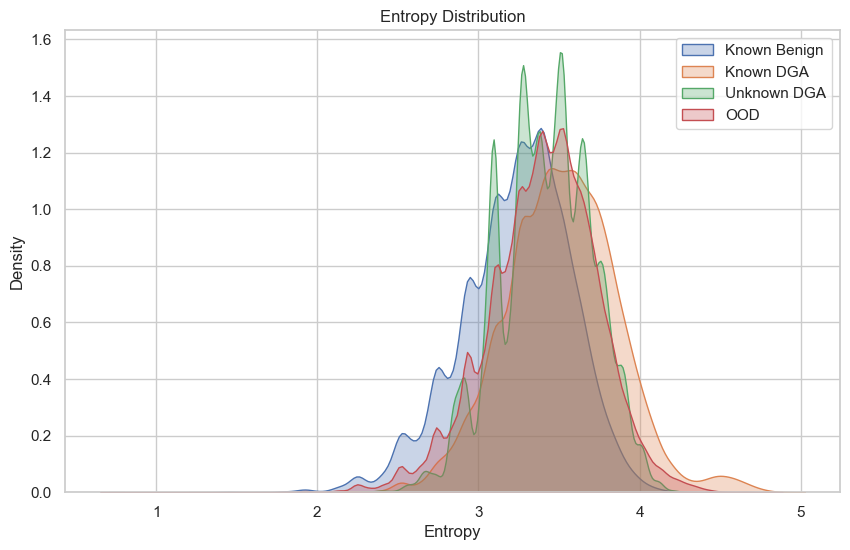

In [ ]:
# Entropy
plt.figure(figsize=(10,6))

for group in df_all["group"].unique():
    subset = df_all[df_all["group"] == group]
    sns.kdeplot(subset["entropy"], label=group, fill=True, alpha=0.3)

plt.title("Entropy Distribution")
plt.xlabel("Entropy")
plt.legend()
plt.show()


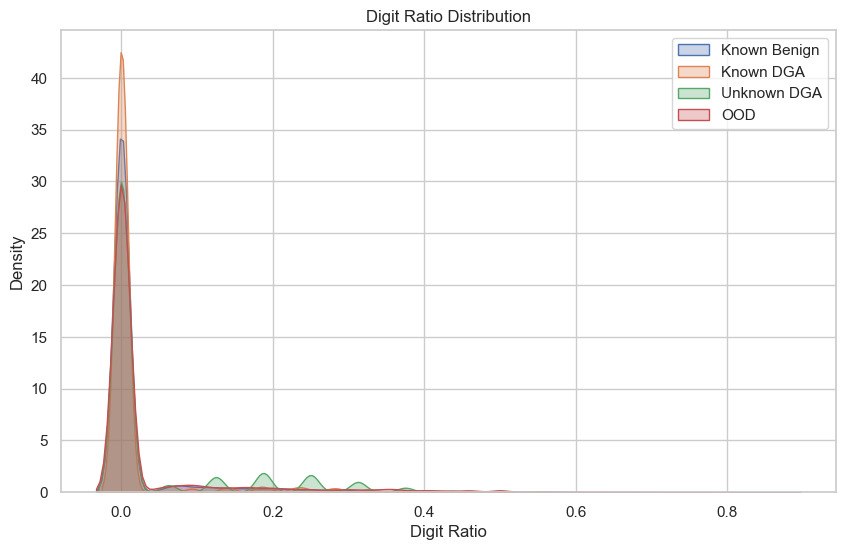

In [ ]:
#Ratio
plt.figure(figsize=(10,6))

for group in df_all["group"].unique():
    subset = df_all[df_all["group"] == group]
    sns.kdeplot(subset["digit_ratio"], label=group, fill=True, alpha=0.3)

plt.title("Digit Ratio Distribution")
plt.xlabel("Digit Ratio")
plt.legend()
plt.show()


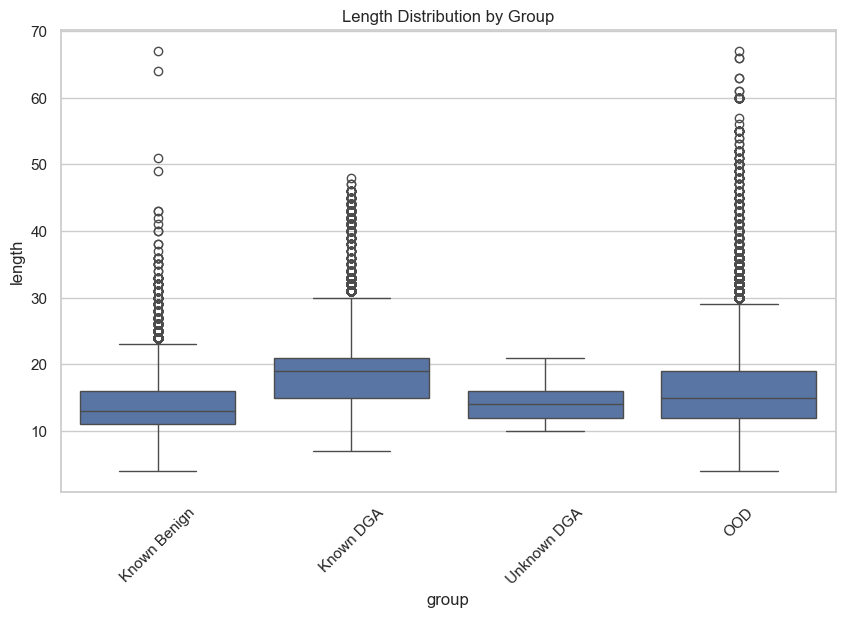

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_all, x="group", y="length")
plt.xticks(rotation=45)
plt.title("Length Distribution by Group")
plt.show()


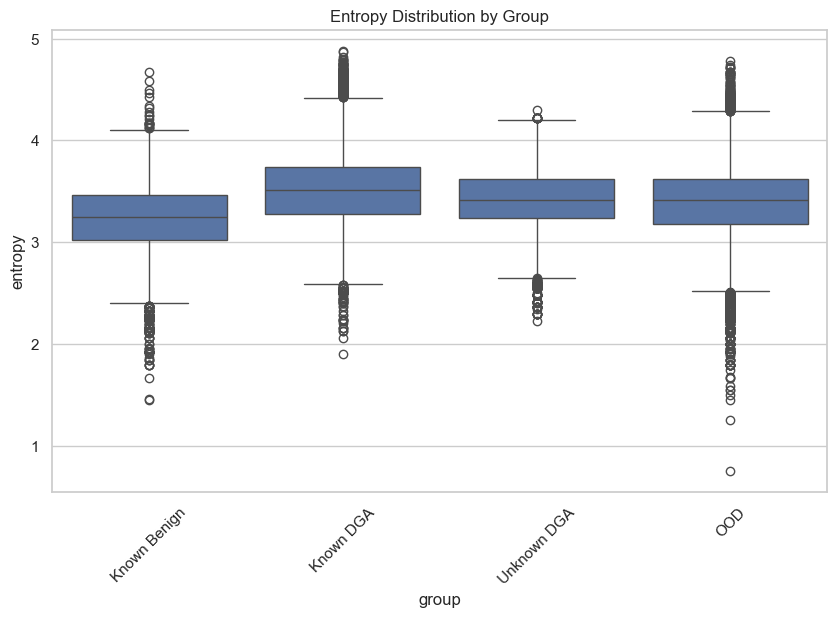

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_all, x="group", y="entropy")
plt.xticks(rotation=45)
plt.title("Entropy Distribution by Group")
plt.show()


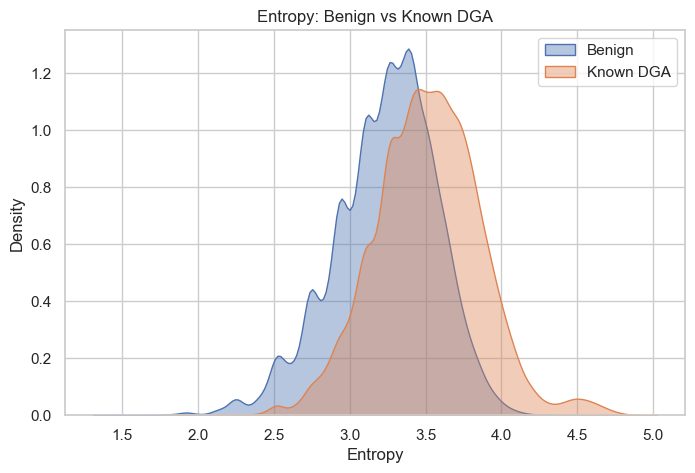

In [18]:
# So sánh entropy giữa Benign vs DGA (ID)
plt.figure(figsize=(8,5))

sns.kdeplot(df_test_known[df_test_known["label"]=="benign"]["entropy"],
            label="Benign", fill=True, alpha=0.4)

sns.kdeplot(df_test_known[df_test_known["label"]=="dga"]["entropy"],
            label="Known DGA", fill=True, alpha=0.4)

plt.title("Entropy: Benign vs Known DGA")
plt.xlabel("Entropy")
plt.legend()
plt.show()


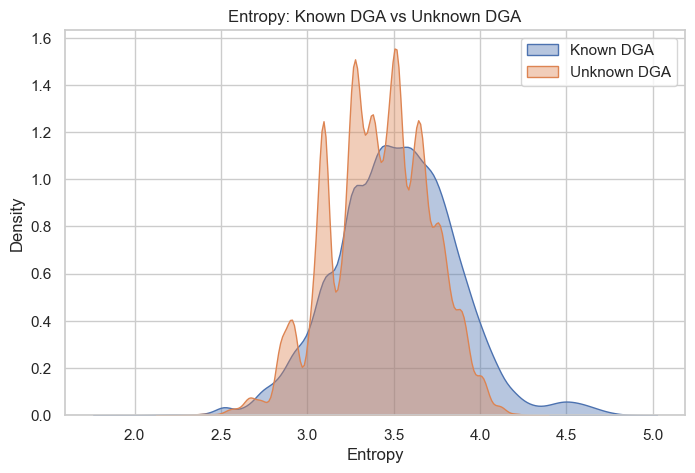

In [19]:
# So sánh entropy giữa Known DGA vs Unknown DGA
plt.figure(figsize=(8,5))

sns.kdeplot(df_known_dga["entropy"],
            label="Known DGA", fill=True, alpha=0.4)

sns.kdeplot(df_unknown_family["entropy"],
            label="Unknown DGA", fill=True, alpha=0.4)

plt.title("Entropy: Known DGA vs Unknown DGA")
plt.xlabel("Entropy")
plt.legend()
plt.show()


### Vowel Ratio & Consonant Ratio

In [20]:
vowels = set("aeiou")

def add_char_features(df):
    df = df.copy()
    
    def vowel_ratio(domain):
        letters = [c for c in domain if c.isalpha()]
        if len(letters) == 0:
            return 0
        return sum(c in vowels for c in letters) / len(letters)
    
    df["vowel_ratio"] = df["domain"].apply(vowel_ratio)
    df["consonant_ratio"] = 1 - df["vowel_ratio"]
    
    return df

df_all = add_char_features(df_all)



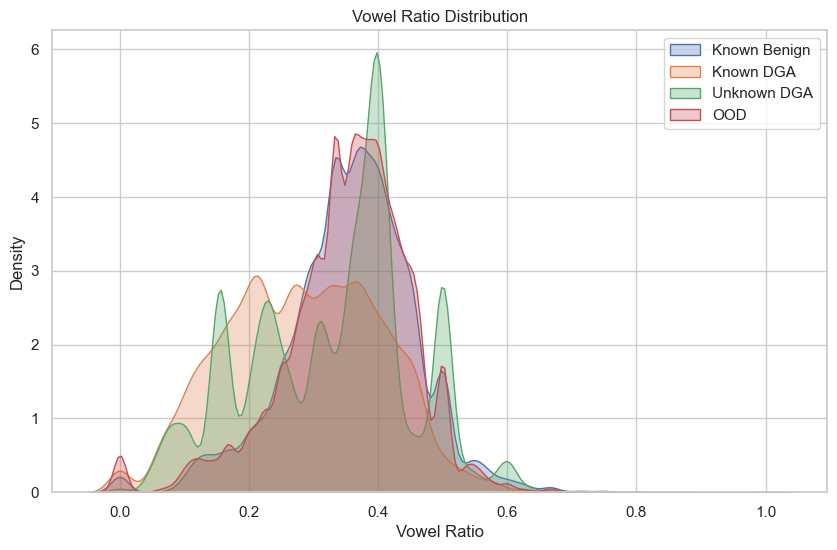

In [21]:
plt.figure(figsize=(10,6))

for group in df_all["group"].unique():
    subset = df_all[df_all["group"] == group]
    sns.kdeplot(subset["vowel_ratio"], label=group, fill=True, alpha=0.3)

plt.title("Vowel Ratio Distribution")
plt.xlabel("Vowel Ratio")
plt.legend()
plt.show()


### N-gram diversity

In [22]:
def bigram_diversity(domain):
    domain = domain.lower()
    bigrams = [domain[i:i+2] for i in range(len(domain)-1)]
    if len(bigrams) == 0:
        return 0
    return len(set(bigrams)) / len(bigrams)

df_all["bigram_diversity"] = df_all["domain"].apply(bigram_diversity)


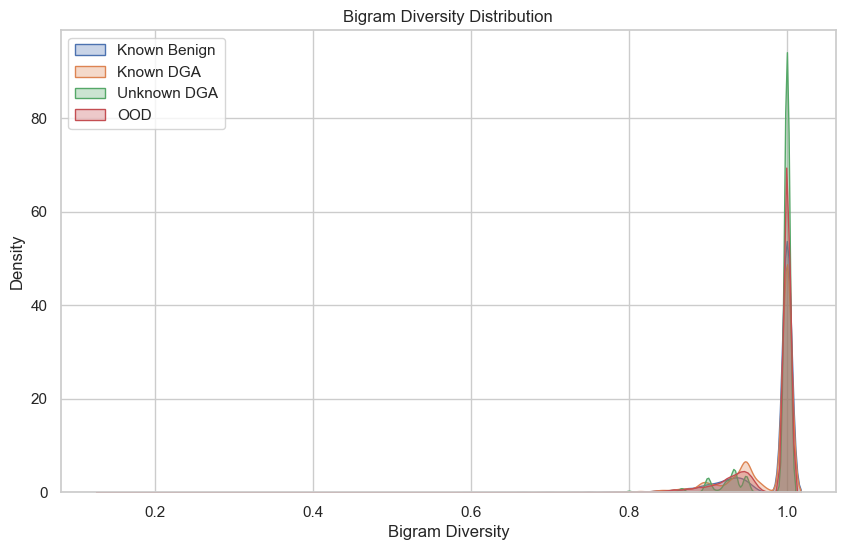

In [23]:
plt.figure(figsize=(10,6))

for group in df_all["group"].unique():
    subset = df_all[df_all["group"] == group]
    sns.kdeplot(subset["bigram_diversity"], label=group, fill=True, alpha=0.3)

plt.title("Bigram Diversity Distribution")
plt.xlabel("Bigram Diversity")
plt.legend()
plt.show()


### TLD Distribution

In [24]:
def extract_tld(domain):
    parts = domain.split(".")
    return parts[-1] if len(parts) > 1 else ""

df_all["tld"] = df_all["domain"].apply(extract_tld)


In [25]:
for group in df_all["group"].unique():
    print(f"\nTop TLD - {group}")
    print(df_all[df_all["group"]==group]["tld"].value_counts().head(5))



Top TLD - Known Benign
tld
com    8683
net    1031
ru      877
org     768
de      526
Name: count, dtype: int64

Top TLD - Known DGA
tld
com     6829
net     2181
org     1768
eu      1417
info    1298
Name: count, dtype: int64

Top TLD - Unknown DGA
tld
com    21358
ru     10042
net     4648
org     3296
top     3221
Name: count, dtype: int64

Top TLD - OOD
tld
com     44212
net      5530
top      2686
org      2333
info     2259
Name: count, dtype: int64
